# RunGATModel 测试 - 2022世界杯决赛

本notebook用于测试GAT模型在2022世界杯决赛数据上的运行

**比赛**: 阿根廷 vs 法国 (Game ID: 10517)

**测试内容**:
1. 数据加载
2. 图构建
3. 特征缩放
4. 数据转换
5. 模型训练

## 1. 导入必要的库

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import pickle
import sys

# 添加父目录到Python路径（用于导入项目模块）
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"✓ 已添加父目录到Python路径: {parent_dir}")

import convert_tracking as ct
import plot_functions as pf
import create_graph as cg
import scale_graph as sg
import GNNs.model_training as mt
import GNNs.convert_data as cd
import GNNs.GAT as GAT

print("✓ 所有库导入成功")

✓ 已添加父目录到Python路径: e:\JerryWu\Master\SoccerAnalytics\TrackingData_literature_code\Evaluating Defensive Influence Using GATs-main (modified for 2022 WC)


Matplotlib is building the font cache; this may take a moment.


✓ 所有库导入成功


## 2. 配置参数

In [2]:
# 2022世界杯决赛ID
GAME_ID = '10517'
DATA_DIR = f'Data/{GAME_ID}'

print(f"使用比赛ID: {GAME_ID}")
print(f"数据目录: {DATA_DIR}")

使用比赛ID: 10517
数据目录: Data/10517


## 3. 加载元数据和处理后的数据

In [3]:
# 加载元数据
print("加载元数据...")
(home_team_id, away_team_id, home_team_name, away_team_name, home_team_start_left,
 home_roster, away_roster,
 roster_game_home_name_dict, roster_game_home_team_name_dict, roster_game_home_pos_dict,
 roster_game_away_name_dict, roster_game_away_team_name_dict, roster_game_away_pos_dict,
 pitch_x_adjustment, pitch_y_adjustment) = ct.get_metadata(GAME_ID)

print(f"✓ 元数据加载成功")
print(f"  主队: {home_team_name}")
print(f"  客队: {away_team_name}")
print(f"  主队开球方向: {'左' if home_team_start_left else '右'}")

加载元数据...
✓ 元数据加载成功
  主队: Argentina
  客队: France
  主队开球方向: 左


In [4]:
# 加载处理后的数据框
print("\n加载处理后的数据...")
balls_df = pd.read_csv(f'{DATA_DIR}/balls_{GAME_ID}.csv')
events_df = pd.read_csv(f'{DATA_DIR}/events_{GAME_ID}.csv')
players_df = pd.read_csv(f'{DATA_DIR}/players_{GAME_ID}.csv')

print(f"✓ 数据加载成功")
print(f"  球数据: {len(balls_df)} 帧")
print(f"  事件数据: {len(events_df)} 个事件")
print(f"  球员数据: {len(players_df)} 条记录")
print(f"  球员数量: {players_df['playerName'].nunique()}")


加载处理后的数据...
✓ 数据加载成功
  球数据: 253828 帧
  事件数据: 1700 个事件
  球员数据: 5584215 条记录
  球员数量: 35


## 4. 测试单个图的创建

In [5]:
# 选择一个测试帧（使用第11个事件）
test_frame = events_df['frameNum'].iloc[10]
print(f"测试帧: {test_frame}")

# 创建图
print("\n创建图...")
G = cg.create_normalized_graph_directed(
    players_df, balls_df, events_df, test_frame, home_team_name
)

if G is not None:
    print(f"✓ 图创建成功")
    print(f"  节点数: {G.number_of_nodes()}")
    print(f"  边数: {G.number_of_edges()}")
    
    # 检查节点特征
    sample_node = list(G.nodes())[0]
    features = G.nodes[sample_node]['features']
    print(f"  节点特征维度: {len(features)}")
    
    # 检查边特征
    sample_edge = list(G.edges())[0]
    edge_features = G.edges[sample_edge]['features']
    print(f"  边特征维度: {len(edge_features)}")
else:
    print("✗ 图创建失败")

测试帧: 6074

创建图...
✓ 图创建成功
  节点数: 23
  边数: 506
  节点特征维度: 15
  边特征维度: 6


## 5. 可视化测试图（可选）

可视化球员位置...
✓ 可视化完成


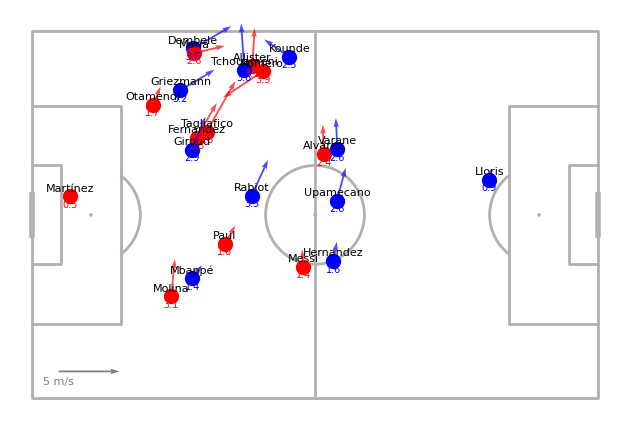

In [6]:
# 可视化球员位置
if G is not None:
    print("可视化球员位置...")
    fig, ax = pf.plot_players_on_pitch(
        players_df[players_df['frameNum'] == test_frame],
        balls_df[balls_df['frameNum'] == test_frame],
        annotate=True,
        show_velocities=True
    )
    print("✓ 可视化完成")

可视化图结构...


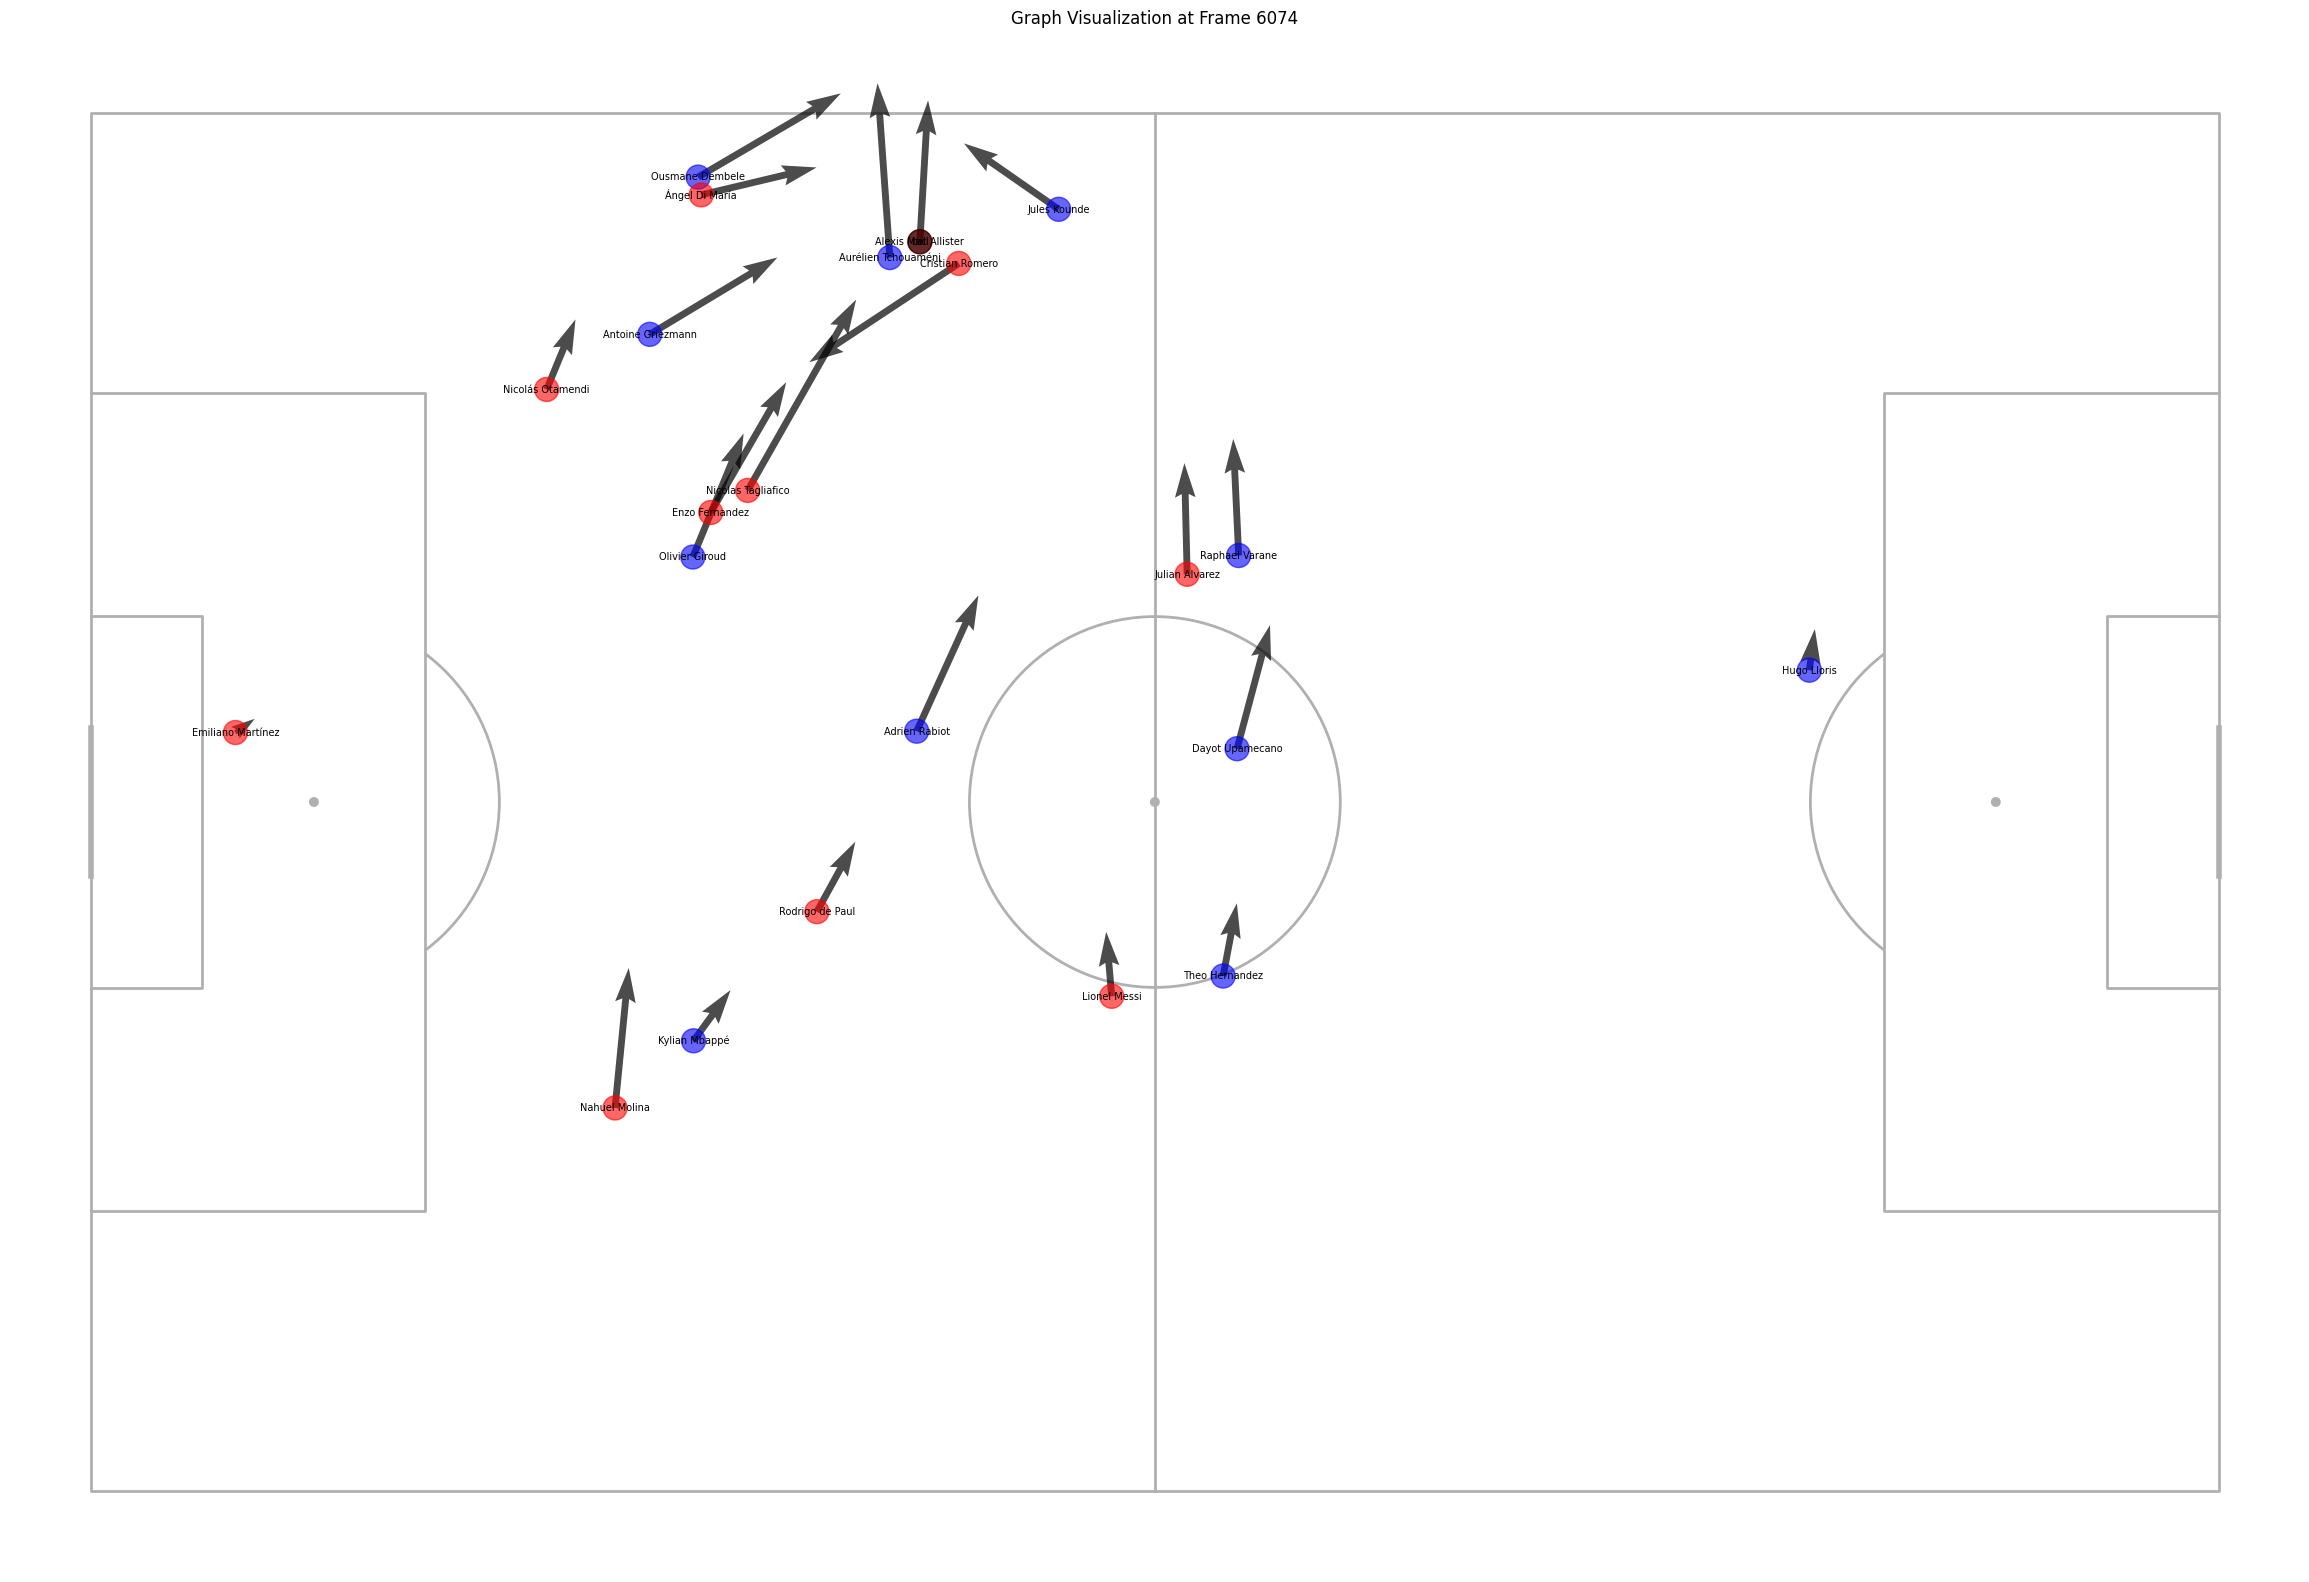

✓ 图可视化完成


In [7]:
# 可视化图结构
if G is not None:
    print("可视化图结构...")
    pf.visualize_graph_on_pitch_AT(G, test_frame)
    print("✓ 图可视化完成")

## 6. 创建多个图（用于训练）

In [8]:
# 为前N个事件帧创建图
MAX_GRAPHS = 100  # 可以调整这个数字

print(f"为前{MAX_GRAPHS}个事件帧创建图...")
graphs = []
frame_numbers = []

event_frames = events_df['frameNum'].values[:MAX_GRAPHS]
success_count = 0
fail_count = 0

for i, frameNum in enumerate(event_frames):
    try:
        G = cg.create_normalized_graph_directed(
            players_df, balls_df, events_df, frameNum, home_team_name
        )
        
        if G is not None:
            graphs.append(G)
            frame_numbers.append(frameNum)
            success_count += 1
        else:
            fail_count += 1
            
        if (i + 1) % 20 == 0:
            print(f"  进度: {i + 1}/{len(event_frames)} 帧已处理")
            
    except Exception as e:
        fail_count += 1
        if fail_count <= 3:
            print(f"  警告: 帧 {frameNum} 失败: {e}")

print(f"\n✓ 图创建完成")
print(f"  成功: {success_count}")
print(f"  失败: {fail_count}")
print(f"  总图数: {len(graphs)}")

为前100个事件帧创建图...
  进度: 20/100 帧已处理
  进度: 40/100 帧已处理
  进度: 60/100 帧已处理
  进度: 80/100 帧已处理
  进度: 100/100 帧已处理

✓ 图创建完成
  成功: 88
  失败: 12
  总图数: 88


## 7. 图特征缩放

In [9]:
print(f"缩放 {len(graphs)} 个图...")

# 创建并拟合缩放器
graph_scaler = sg.GraphFeatureScaler()
graph_scaler.fit(graphs)
print("✓ 缩放器已拟合")

# 转换图
scaled_graphs = [graph_scaler.transform_graph(G) for G in graphs]
print(f"✓ 图已缩放: {len(scaled_graphs)}")

# 验证缩放
original_features = graphs[0].nodes[list(graphs[0].nodes())[0]]['features']
scaled_features = scaled_graphs[0].nodes[list(scaled_graphs[0].nodes())[0]]['features']

print(f"\n特征对比（第一个节点）:")
print(f"  原始特征范围: [{original_features.min():.2f}, {original_features.max():.2f}]")
print(f"  缩放后特征范围: [{scaled_features.min():.2f}, {scaled_features.max():.2f}]")

缩放 88 个图...
✓ 缩放器已拟合
✓ 图已缩放: 88

特征对比（第一个节点）:
  原始特征范围: [-43.34, 61.66]
  缩放后特征范围: [-0.90, 1.00]


## 8. 转换为PyTorch Geometric格式

In [10]:
print("转换图为PyTorch Geometric格式...")
dataset = cd.prepare_dataset_reception(scaled_graphs)
print(f"✓ 数据集创建完成: {len(dataset)} 个图")

# 检查第一个数据对象
data = dataset[0]
print(f"\n数据对象属性:")
print(f"  节点特征形状: {data.x.shape}")
print(f"  边索引形状: {data.edge_index.shape}")
print(f"  边特征形状: {data.edge_attr.shape}")
print(f"  目标形状: {data.y.shape}")
print(f"  进攻球员掩码形状: {data.attacking_player_mask.shape}")
print(f"  进攻球员数量: {data.attacking_player_mask.sum().item()}")

转换图为PyTorch Geometric格式...
✓ 数据集创建完成: 88 个图

数据对象属性:
  节点特征形状: torch.Size([23, 15])
  边索引形状: torch.Size([2, 506])
  边特征形状: torch.Size([506, 6])
  目标形状: torch.Size([23])
  进攻球员掩码形状: torch.Size([23])
  进攻球员数量: 11


## 9. 训练GAT模型（小规模测试）

In [11]:
print(f"训练GAT模型（{len(scaled_graphs)} 个图）...")
print("注意: 使用小参数进行快速测试\n")

# 使用最小参数进行测试
model_reception_AT, train_loader_AT, test_loader_AT = mt.train_reception_prediction_AT_model(
    scaled_graphs,
    num_epochs=10,  # 少量epoch用于测试
    batch_size=16,
    hidden_channels=32,
    edge_hidden_channels=16,
    lr=0.001
)

print(f"\n✓ 模型训练完成")
print(f"  训练批次: {len(train_loader_AT)}")
print(f"  测试批次: {len(test_loader_AT)}")

训练GAT模型（88 个图）...
注意: 使用小参数进行快速测试

Epoch 0: Train Loss: 0.6348, Val Loss: 0.6152, AUC: 0.5203
Epoch 2: Train Loss: 0.5413, Val Loss: 0.5267, AUC: 0.5102
Epoch 4: Train Loss: 0.4467, Val Loss: 0.4337, AUC: 0.5206
Epoch 6: Train Loss: 0.3495, Val Loss: 0.3373, AUC: 0.5271
Epoch 8: Train Loss: 0.2803, Val Loss: 0.2969, AUC: 0.5583

✓ 模型训练完成
  训练批次: 5
  测试批次: 2


## 10. 测试模型预测

In [12]:
# 在一个测试图上进行预测
import visualisation

print("测试模型预测...")
test_graph_idx = 40  # 使用第41个图

if test_graph_idx < len(scaled_graphs):
    results_df, attention_analysis = visualisation.predict_reception_probabilities(
        model_reception_AT,
        scaled_graphs[test_graph_idx],
        head_indexes=range(2)  # 使用前2个注意力头
    )
    
    print("\n✓ 预测完成")
    print("\n接球概率（前5名）:")
    print(results_df.head())
    
    print("\n注意力权重示例（第一个球员）:")
    first_player = results_df['player_name'].iloc[0]
    if first_player in attention_analysis:
        print(f"\n{first_player} 的注意力权重（前5）:")
        for i, attn in enumerate(attention_analysis[first_player][:5]):
            print(f"  {i+1}. {attn['source_player']}: {attn['attention_weight']:.4f}")
else:
    print(f"测试图索引 {test_graph_idx} 超出范围")

测试模型预测...

✓ 预测完成

接球概率（前5名）:
          player_name  is_attacking  reception_probability_AT
7  Nicolas Tagliafico          True                  0.059895
9     Rodrigo de Paul          True                  0.059260
5        Lionel Messi          True                  0.058093
6       Nahuel Molina          True                  0.057348
3      Enzo Fernandez          True                  0.053291

注意力权重示例（第一个球员）:

Nicolas Tagliafico 的注意力权重（前5）:
  1. Hugo Lloris: 0.0539
  2. Dayot Upamecano: 0.0504
  3. Raphael Varane: 0.0503
  4. Jules Kounde: 0.0501
  5. Aurélien Tchouaméni: 0.0497


## 11. 保存模型和缩放器（可选）

In [13]:
# 保存模型
import torch

save_model = True  # 设置为True以保存模型，设置为False以保存模型

if save_model:
    model_path = f'results/model_final_{GAME_ID}.pth'
    scaler_path = f'results/scaler_final_{GAME_ID}.pkl'
    
    # 创建results目录
    os.makedirs('results', exist_ok=True)
    
    # 保存模型
    torch.save(model_reception_AT.state_dict(), model_path)
    print(f"✓ 模型已保存到: {model_path}")
    
    # 保存缩放器
    with open(scaler_path, 'wb') as f:
        pickle.dump(graph_scaler, f)
    print(f"✓ 缩放器已保存到: {scaler_path}")
else:
    print("跳过模型保存（设置 save_model=True 以保存）")

✓ 模型已保存到: results/model_final_10517.pth
✓ 缩放器已保存到: results/scaler_final_10517.pkl


## 总结

本notebook成功完成了以下测试：

✓ 数据加载（2022世界杯决赛）  
✓ 图构建  
✓ 特征缩放  
✓ PyTorch Geometric数据转换  
✓ GAT模型训练  
✓ 模型预测和注意力分析  

**下一步**:
- 增加训练epoch数以获得更好的性能
- 使用更多比赛数据进行训练
- 调整模型超参数
- 进行更详细的模型评估